# Cab Price Predictor — Exploratory Data Analysis

**Structure:**
1. Load & Overview
2. Sanity / Realism Checks
3. Business Breakdowns (city, time, weather, cab type, holiday)
4. Correlation Matrix
5. Categorical Distribution Checks
6. Business Insight — Supply Optimization Opportunity


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.join(os.getcwd(), '..'))
from config.config import CITIES

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = os.path.join("..", "data", "processed", "cab_dataset.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (9435, 27)


,route_id,city,city_tier,source_lat,source_lng,dest_lat,dest_lng,source_subregion,source_zone,dest_subregion,...,is_holiday,weather_condition,traffic_level,cab_type,cab_availability,surge_multiplier,base_price_per_km,per_minute_rate,estimated_time_min,fare_amount
0,0,Mumbai,1,19.01485,72.84165,18.921995,72.820225,Dadar Station,Railway,Nariman Point,...,0,Rainy,High,SUV,15,1.43,21.0,2.5,28.03,724.19
1,0,Mumbai,1,19.01485,72.84165,18.921995,72.820225,Dadar Station,Railway,Nariman Point,...,0,Cloudy,Medium,SUV,15,1.20,21.0,2.5,22.12,588.87
2,0,Mumbai,1,19.01485,72.84165,18.921995,72.820225,Dadar Station,Railway,Nariman Point,...,0,Sunny,Low,Mini,15,1.17,21.0,2.5,20.90,467.08
3,0,Mumbai,1,19.01485,72.84165,18.921995,72.820225,Dadar Station,Railway,Nariman Point,...,0,Sunny,Medium,Sedan,15,1.23,21.0,2.5,25.93,502.37
4,0,Mumbai,1,19.01485,72.84165,18.921995,72.820225,Dadar Station,Railway,Nariman Point,...,0,Sunny,Low,Sedan,15,1.09,21.0,2.5,17.52,370.08


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   route_id            9435 non-null   int64  
 1   city                9435 non-null   object 
 2   city_tier           9435 non-null   int64  
 3   source_lat          9435 non-null   float64
 4   source_lng          9435 non-null   float64
 5   dest_lat            9435 non-null   float64
 6   dest_lng            9435 non-null   float64
 7   source_subregion    9435 non-null   object 
 8   source_zone         9435 non-null   object 
 9   dest_subregion      9435 non-null   object 
 10  dest_zone           9435 non-null   object 
 11  distance_km         9435 non-null   float64
 12  base_time_min       9435 non-null   float64
 13  timestamp           9435 non-null   object 
 14  time_of_day         9435 non-null   object 
 15  day_of_week         9435 non-null   object 
 16  hour  

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
route_id,9435.0,NaN,NaN,NaN,987.99682,566.283861,0.0,498.0,996.0,1479.0,1959.0
city,9435,5,Bengaluru,1955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_tier,9435.0,NaN,NaN,NaN,1.393747,0.488606,1.0,1.0,1.0,2.0,2.0
source_lat,9435.0,NaN,NaN,NaN,21.539885,6.737659,12.840628,17.388807,19.062258,28.631464,30.754828
source_lng,9435.0,NaN,NaN,NaN,76.593556,1.947072,72.807082,76.750225,77.218895,77.70174,78.571771
dest_lat,9435.0,NaN,NaN,NaN,21.540205,6.741314,12.840576,17.385155,19.090207,28.634127,30.753943
dest_lng,9435.0,NaN,NaN,NaN,76.595014,1.945774,72.807123,76.749316,77.227185,77.685217,78.573075
source_subregion,9435,76,Sector 35,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_zone,9435,4,Suburb,3170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_subregion,9435,76,Sector 22,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Sanity / Realism Checks

Before trusting this dataset for modeling, we confirm it actually obeys the rules
we baked into the generation logic (config.py + fare_calculator.py). If these checks
fail, something upstream in the pipeline is broken.


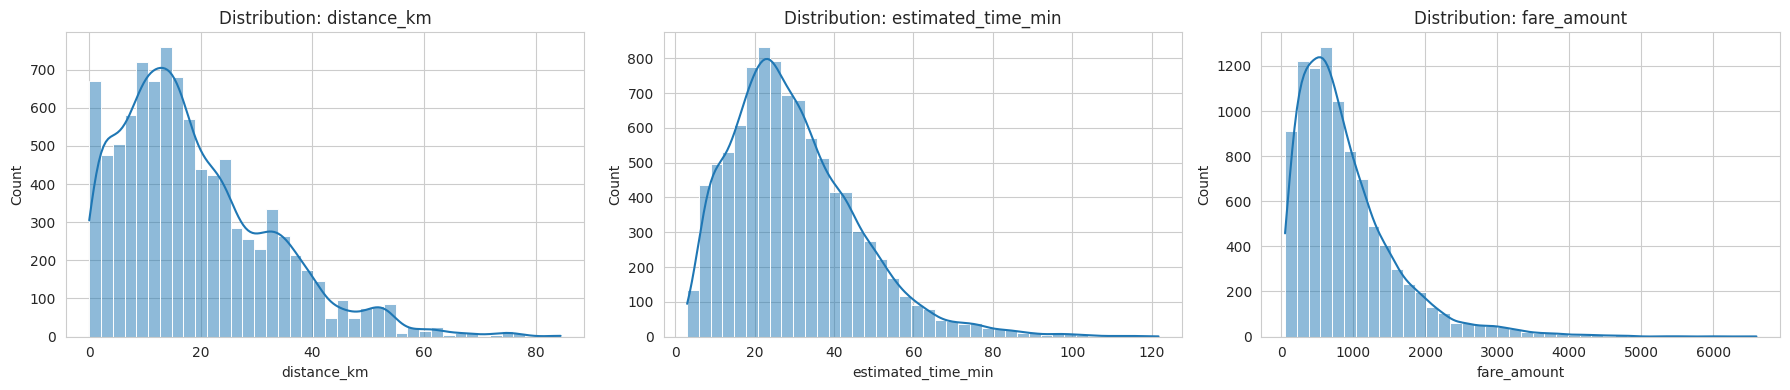

Negative values check:
  distance_km: 0 negative rows
  estimated_time_min: 0 negative rows
  fare_amount: 0 negative rows


In [4]:
# Distribution of core numeric columns — should be right-skewed, no negatives
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["distance_km", "estimated_time_min", "fare_amount"]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

print("Negative values check:")
for col in ["distance_km", "estimated_time_min", "fare_amount"]:
    print(f"  {col}: {(df[col] < 0).sum()} negative rows")

In [5]:
# Surge multiplier must stay within [1.0, 2.0] per MoRTH cap baked into config
print("Surge multiplier range:", df["surge_multiplier"].min(), "-", df["surge_multiplier"].max())
assert df["surge_multiplier"].between(1.0, 2.0).all(), "Surge multiplier breached the 1.0-2.0 bound!"
print("✅ Surge multiplier respects the [1.0, 2.0] cap")

Surge multiplier range: 1.0 - 2.0
✅ Surge multiplier respects the [1.0, 2.0] cap


In [6]:
# Fare must never fall below each city's configured minimum_fare
violations = 0
for city, info in CITIES.items():
    min_fare = info["minimum_fare"]
    bad_rows = df[(df["city"] == city) & (df["fare_amount"] < min_fare)]
    if len(bad_rows) > 0:
        print(f"  ⚠️  {city}: {len(bad_rows)} rows below minimum_fare (₹{min_fare})")
        violations += len(bad_rows)

if violations == 0:
    print("✅ No rows violate their city's minimum fare")
else:
    print(f"❌ {violations} total rows violate minimum fare — investigate fare_calculator.py")

✅ No rows violate their city's minimum fare


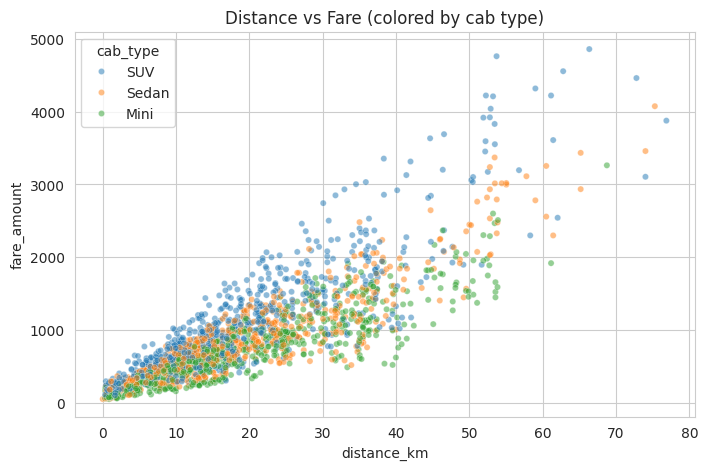

In [7]:
# distance_km vs fare_amount — should show a clear positive trend with noise scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(2000, len(df))), x="distance_km", y="fare_amount",
                 hue="cab_type", alpha=0.5, s=20)
plt.title("Distance vs Fare (colored by cab type)")
plt.show()

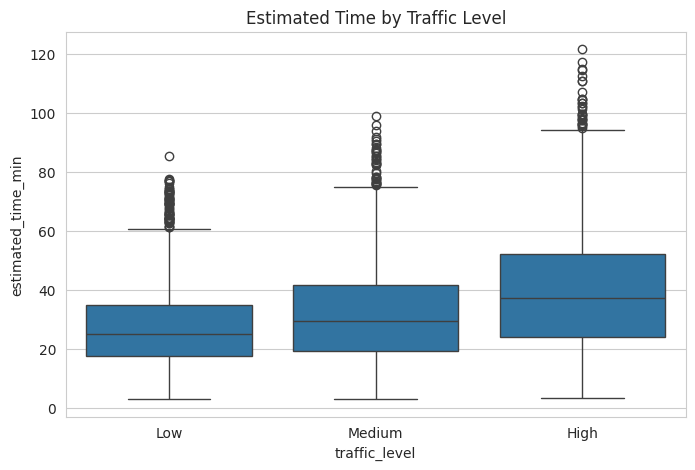

traffic_level
Low       26.870057
Medium    31.752075
High      40.065546
Name: estimated_time_min, dtype: float64


In [8]:
# traffic_level vs estimated_time_min — High traffic should consistently take longer
order = ["Low", "Medium", "High"]
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="traffic_level", y="estimated_time_min", order=order)
plt.title("Estimated Time by Traffic Level")
plt.show()

print(df.groupby("traffic_level")["estimated_time_min"].mean().reindex(order))

## 3. Business Breakdowns

These checks confirm the dataset tells the *business* story we expect — city pricing
tiers, time-of-day premiums, weather-driven surge, cab type ordering, and holiday effects —
all consistent with what we configured in `config.py`.


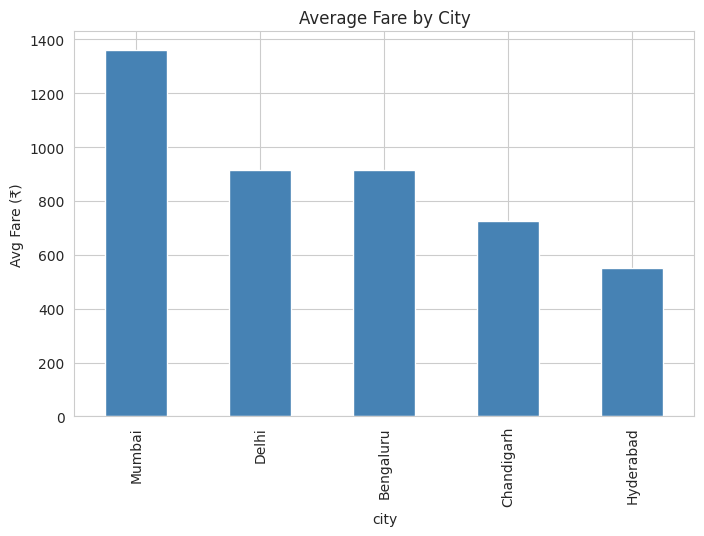

city
Mumbai        1361.914895
Delhi          916.220080
Bengaluru      913.180312
Chandigarh     727.149859
Hyderabad      552.348195
Name: fare_amount, dtype: float64

In [9]:
# Average fare per city — should roughly track each city's base_price_per_km ordering
city_fare = df.groupby("city")["fare_amount"].mean().sort_values(ascending=False)
city_fare.plot(kind="bar", color="steelblue", figsize=(8, 5))
plt.title("Average Fare by City")
plt.ylabel("Avg Fare (₹)")
plt.show()
city_fare

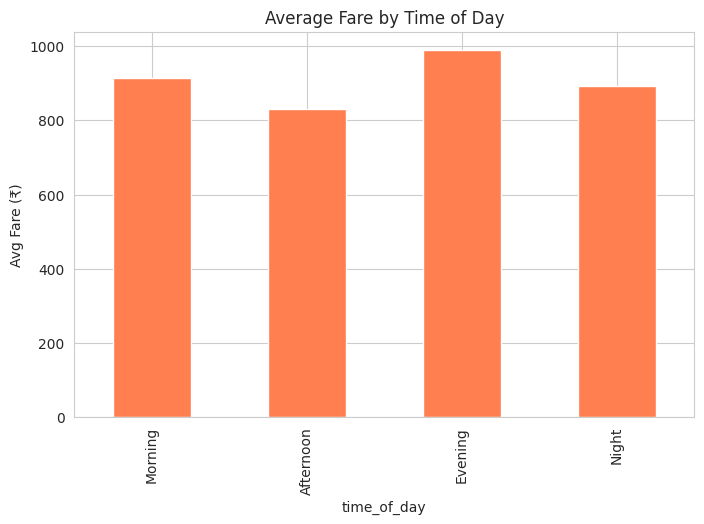

time_of_day
Morning      913.519586
Afternoon    831.087244
Evening      989.583579
Night        893.275701
Name: fare_amount, dtype: float64

In [10]:
# Average fare by time_of_day — Night should show the premium bump
order_tod = ["Morning", "Afternoon", "Evening", "Night"]
tod_fare = df.groupby("time_of_day")["fare_amount"].mean().reindex(order_tod)
tod_fare.plot(kind="bar", color="coral", figsize=(8, 5))
plt.title("Average Fare by Time of Day")
plt.ylabel("Avg Fare (₹)")
plt.show()
tod_fare

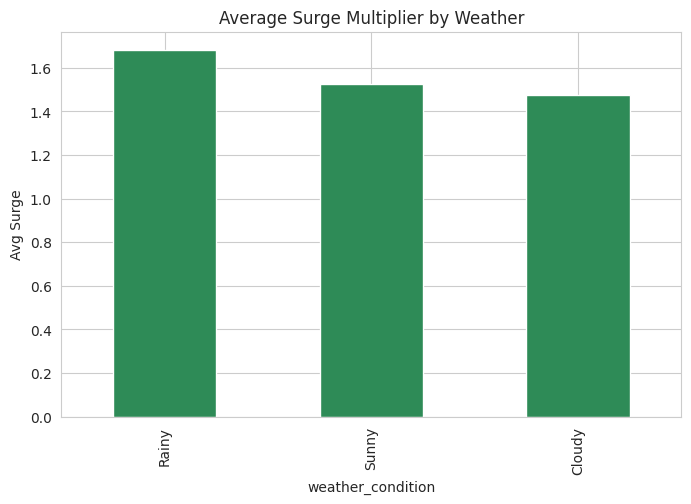

weather_condition
Rainy     1.681542
Sunny     1.525566
Cloudy    1.473072
Name: surge_multiplier, dtype: float64

In [11]:
# Average surge by weather — Rainy/Stormy should show higher surge than Sunny
weather_surge = df.groupby("weather_condition")["surge_multiplier"].mean().sort_values(ascending=False)
weather_surge.plot(kind="bar", color="seagreen", figsize=(8, 5))
plt.title("Average Surge Multiplier by Weather")
plt.ylabel("Avg Surge")
plt.show()
weather_surge

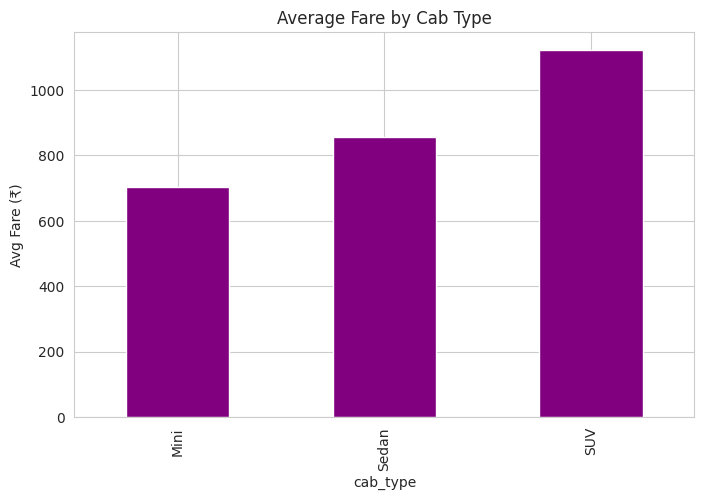

cab_type
Mini      703.849383
Sedan     855.111270
SUV      1121.163410
Name: fare_amount, dtype: float64

In [12]:
# Average fare by cab type — should hold Mini < Sedan < SUV
cab_fare = df.groupby("cab_type")["fare_amount"].mean().reindex(["Mini", "Sedan", "SUV"])
cab_fare.plot(kind="bar", color="purple", figsize=(8, 5))
plt.title("Average Fare by Cab Type")
plt.ylabel("Avg Fare (₹)")
plt.show()
cab_fare

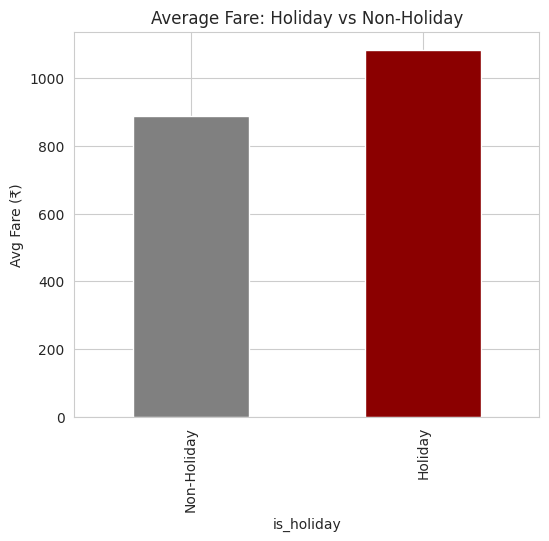

is_holiday
Non-Holiday     888.354520
Holiday        1083.287397
Name: fare_amount, dtype: float64

In [13]:
# Holiday vs non-holiday average fare
holiday_fare = df.groupby("is_holiday")["fare_amount"].mean()
holiday_fare.index = holiday_fare.index.map({0: "Non-Holiday", 1: "Holiday"})
holiday_fare.plot(kind="bar", color=["gray", "darkred"], figsize=(6, 5))
plt.title("Average Fare: Holiday vs Non-Holiday")
plt.ylabel("Avg Fare (₹)")
plt.show()
holiday_fare

## 4. Correlation Matrix

A correlation heatmap shows which numeric features actually drive
`fare_amount` and `estimated_time_min`, and flags any redundant/multicollinear features
worth dropping before modeling.


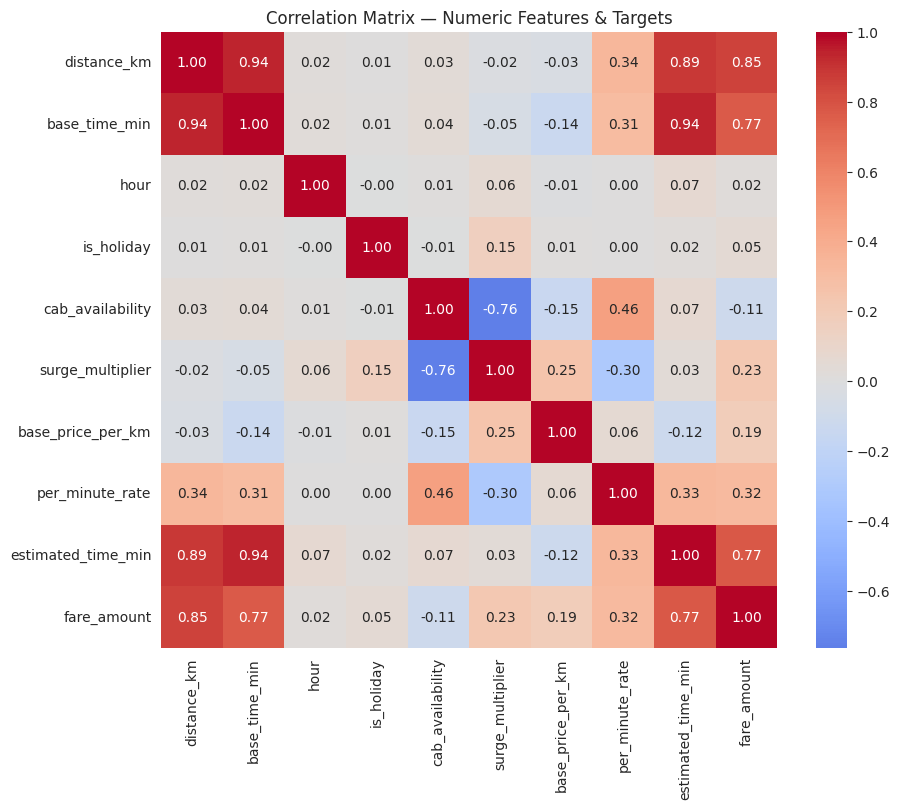

In [14]:
numeric_cols = [
    "distance_km", "base_time_min", "hour", "is_holiday",
    "cab_availability", "surge_multiplier", "base_price_per_km",
    "per_minute_rate", "estimated_time_min", "fare_amount"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Numeric Features & Targets")
plt.show()

## 5. Categorical Distribution Checks

Confirms no city, weather type, or cab type is wildly underrepresented after route
generation — important for making sure the model sees balanced examples of each.


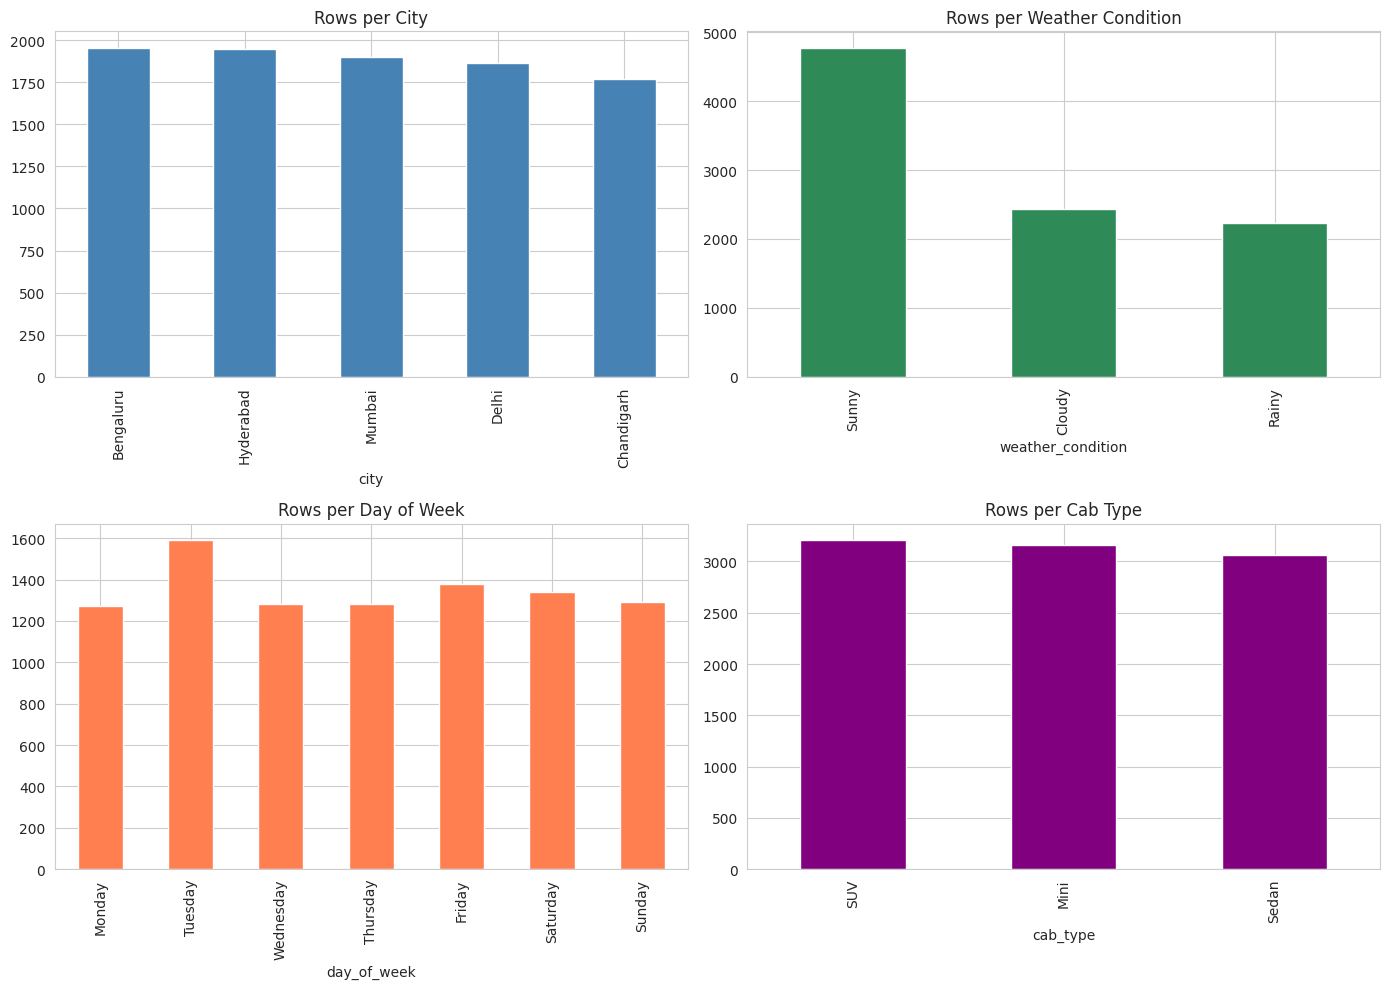

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["city"].value_counts().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Rows per City")

df["weather_condition"].value_counts().plot(kind="bar", ax=axes[0,1], color="seagreen")
axes[0,1].set_title("Rows per Weather Condition")

df["day_of_week"].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", ax=axes[1,0], color="coral")
axes[1,0].set_title("Rows per Day of Week")

df["cab_type"].value_counts().plot(kind="bar", ax=axes[1,1], color="purple")
axes[1,1].set_title("Rows per Cab Type")

plt.tight_layout()
plt.show()

## 6. Business Insight — Supply Optimization Opportunity

**Hypothesis:** zones with consistently *low* `cab_availability` and consistently *high*
`surge_multiplier` represent areas where customers are paying inflated prices due to
**undersupply**, not because the ride itself (distance/time) is genuinely expensive.

These are the zones where deploying more cabs could let the platform undercut
competitor surge pricing while still protecting margins — winning price-sensitive
riders away from competitors charging higher surge rates in the same area.


In [27]:
# Row-level fare_per_km (mean-of-ratios, not ratio-of-means)
df["fare_per_km"] = df["fare_amount"] / df["distance_km"]

# Distance bands: short hops vs long hauls have different fare/km dynamics
df["distance_band"] = pd.cut(
    df["distance_km"],
    bins=[0, 5, 10, 15, 20, 100],
    labels=["0-5km", "5-10km", "10-15km", "15-20km", "20km+"],
    include_lowest=True
)

print("Distance band distribution:")
print(df["distance_band"].value_counts().sort_index())

Distance band distribution:
distance_band
0-5km      1365
5-10km     1360
10-15km    1720
15-20km    1395
20km+      3595
Name: count, dtype: int64


In [ ]:
# This is the key : we compare each zone only against rides of similar length
# in the same city. A 3km airport hop is compared to other 3km rides in that city,
# not to 20km suburb-to-city-center rides.

city_dist_baseline = df.groupby(["city", "distance_band"])["fare_per_km"].mean().reset_index()
city_dist_baseline.rename(columns={"fare_per_km": "baseline_fare_per_km"}, inplace=True)

print("City × Distance band baselines (sample):")
print(city_dist_baseline.head(10))

City × Distance band baselines (sample):
         city distance_band  baseline_fare_per_km
0   Bengaluru         0-5km            154.813807
1   Bengaluru        5-10km             58.377277
2   Bengaluru       10-15km             53.868379
3   Bengaluru       15-20km             51.502098
4   Bengaluru         20km+             48.231067
5  Chandigarh         0-5km            167.842960
6  Chandigarh        5-10km             71.513016
7  Chandigarh       10-15km             63.132179
8  Chandigarh       15-20km             63.648798
9  Chandigarh         20km+             63.797215


/tmp/ipykernel_34340/1519656154.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_dist_baseline = df.groupby(["city", "distance_band"])["fare_per_km"].mean().reset_index()


In [29]:
zone_summary = df.groupby(["city", "source_zone"]).agg(
    avg_surge=("surge_multiplier", "mean"),
    avg_availability=("cab_availability", "mean"),
    avg_fare=("fare_amount", "mean"),
    avg_distance=("distance_km", "mean"),
    median_distance=("distance_km", "median"),
    fare_per_km=("fare_per_km", "mean"),           # mean of row-level ratios
    row_count=("fare_amount", "count"),
    dominant_dist_band=("distance_band", lambda x: x.mode()[0] if not x.mode().empty else "mixed")
).reset_index()

# Merge with city×distance baseline for the zone's DOMINANT distance band
zone_summary = zone_summary.merge(
    city_dist_baseline,
    left_on=["city", "dominant_dist_band"],
    right_on=["city", "distance_band"],
    how="left"
)

# Compute TRUE scarcity premium: zone vs same-city, same-distance-band baseline
zone_summary["scarcity_premium_pct"] = (
    (zone_summary["fare_per_km"] / zone_summary["baseline_fare_per_km"] - 1) * 100
)

print("Zone summary with distance-controlled premium (sample):")
print(zone_summary[["city", "source_zone", "dominant_dist_band", "avg_surge",
                    "avg_availability", "fare_per_km", "baseline_fare_per_km",
                    "scarcity_premium_pct"]].head(10))

Zone summary with distance-controlled premium (sample):
         city  source_zone dominant_dist_band  avg_surge  avg_availability  \
0   Bengaluru      Airport              20km+   1.211160              16.0   
1   Bengaluru  City Center            10-15km   1.472785              11.0   
2   Bengaluru      Railway              20km+   1.488000              13.0   
3   Bengaluru       Suburb              20km+   1.759534               5.0   
4  Chandigarh      Airport            10-15km   1.316294              10.0   
5  Chandigarh  City Center              0-5km   1.720093               7.0   
6  Chandigarh      Railway             5-10km   1.716875               8.0   
7  Chandigarh       Suburb            15-20km   1.989547               3.0   
8       Delhi      Airport            15-20km   1.168145              17.0   
9       Delhi  City Center              20km+   1.396557              13.0   

   fare_per_km  baseline_fare_per_km  scarcity_premium_pct  
0    82.740613          

In [30]:
median_avail = zone_summary["avg_availability"].median()
median_surge = zone_summary["avg_surge"].median()

print(f"\nMedian availability: {median_avail:.1f}")
print(f"Median surge: {median_surge:.2f}x")

expansion_targets = zone_summary[
    (zone_summary["avg_availability"] < median_avail) &
    (zone_summary["avg_surge"] > median_surge)
].sort_values("scarcity_premium_pct", ascending=False)

print(f"\n📍 Expansion-target zones (low availability + high surge): {len(expansion_targets)} zones")
print(expansion_targets[["city", "source_zone", "dominant_dist_band", "avg_availability",
                         "avg_surge", "scarcity_premium_pct", "row_count"]])


Median availability: 11.5
Median surge: 1.46x

📍 Expansion-target zones (low availability + high surge): 8 zones
          city  source_zone dominant_dist_band  avg_availability  avg_surge  \
19      Mumbai       Suburb              20km+               6.0   1.813607   
15   Hyderabad       Suburb              20km+               5.0   1.706628   
3    Bengaluru       Suburb              20km+               5.0   1.759534   
7   Chandigarh       Suburb            15-20km               3.0   1.989547   
1    Bengaluru  City Center            10-15km              11.0   1.472785   
11       Delhi       Suburb              20km+               7.0   1.680477   
6   Chandigarh      Railway             5-10km               8.0   1.716875   
5   Chandigarh  City Center              0-5km               7.0   1.720093   

    scarcity_premium_pct  row_count  
19             36.353266        560  
15             29.620947        605  
3              27.993262        665  
7              19.3536

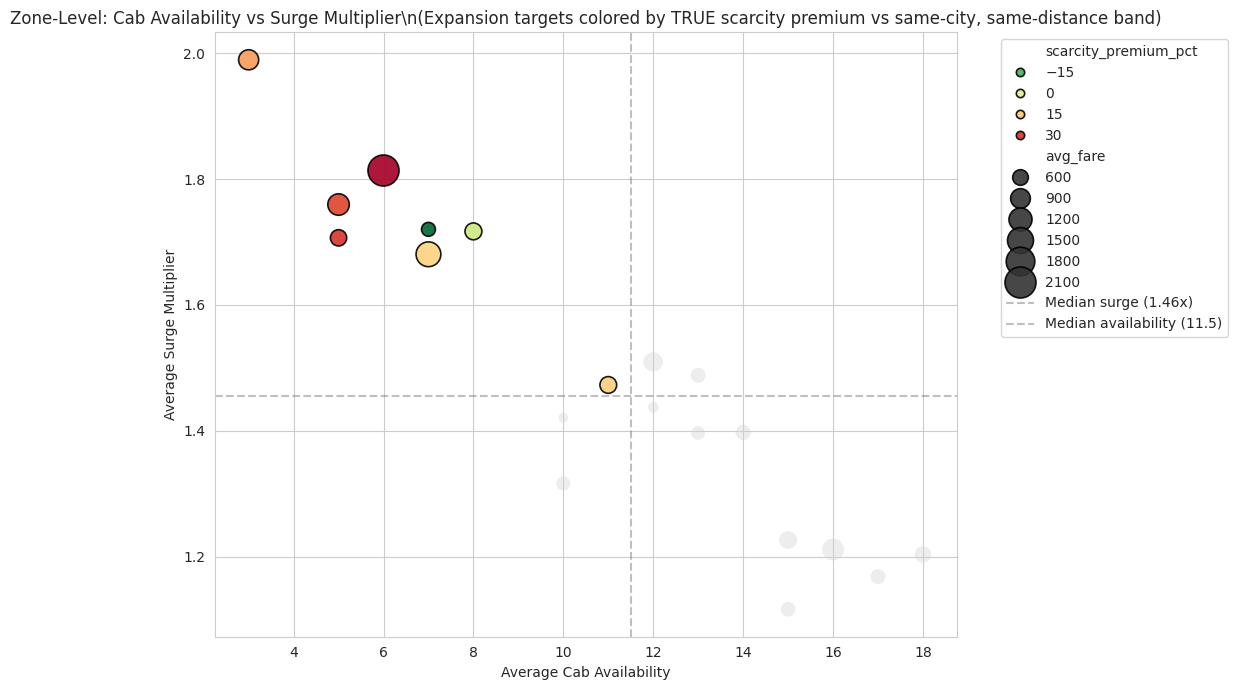

In [31]:
plt.figure(figsize=(11, 7))

# All zones in light gray
scatter = sns.scatterplot(
    data=zone_summary,
    x="avg_availability",
    y="avg_surge",
    size="avg_fare",
    sizes=(50, 400),
    alpha=0.4,
    color="lightgray",
    edgecolor="none",
    legend=False
)

# Expansion targets in color by scarcity premium
sns.scatterplot(
    data=expansion_targets,
    x="avg_availability",
    y="avg_surge",
    hue="scarcity_premium_pct",
    palette="RdYlGn_r",  # Red = high premium (bad for customers)
    size="avg_fare",
    sizes=(100, 500),
    edgecolor="black",
    linewidth=1.2,
    alpha=0.9,
    legend="brief"
)

plt.axhline(median_surge, color="gray", linestyle="--", alpha=0.5, label=f"Median surge ({median_surge:.2f}x)")
plt.axvline(median_avail, color="gray", linestyle="--", alpha=0.5, label=f"Median availability ({median_avail:.1f})")

plt.title("Zone-Level: Cab Availability vs Surge Multiplier\\n(Expansion targets colored by TRUE scarcity premium vs same-city, same-distance band)")
plt.xlabel("Average Cab Availability")
plt.ylabel("Average Surge Multiplier")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [32]:
print("=" * 70)
print("SCARCITY PREMIUM ANALYSIS (Distance-Controlled)")
print("=" * 70)

# Global stats
global_premium = expansion_targets["scarcity_premium_pct"].mean()
print(f"\n📊 Expansion-target zones (n={len(expansion_targets)}):")
print(f"   Average scarcity premium: {global_premium:+.1f}% vs same-city, same-distance band")

# City-level breakdown
print(f"\n📊 Premium breakdown by city (distance-controlled):")
for city in sorted(expansion_targets["city"].unique()):
    city_targets = expansion_targets[expansion_targets["city"] == city]
    avg_premium = city_targets["scarcity_premium_pct"].mean()
    avg_surge = city_targets["avg_surge"].mean()
    print(f"   {city:12s}: {len(city_targets)} zones | "
          f"avg premium {avg_premium:+.1f}% | avg surge {avg_surge:.2f}x")

SCARCITY PREMIUM ANALYSIS (Distance-Controlled)

📊 Expansion-target zones (n=8):
   Average scarcity premium: +14.1% vs same-city, same-distance band

📊 Premium breakdown by city (distance-controlled):
   Bengaluru   : 2 zones | avg premium +20.8% | avg surge 1.62x
   Chandigarh  : 3 zones | avg premium -2.6% | avg surge 1.81x
   Delhi       : 1 zones | avg premium +13.1% | avg surge 1.68x
   Hyderabad   : 1 zones | avg premium +29.6% | avg surge 1.71x
   Mumbai      : 1 zones | avg premium +36.4% | avg surge 1.81x


In [33]:
# This sharpens the recommendation from "more cabs city-wide" to 
# "more cabs at specific hours in specific zones"

print("\n" + "=" * 70)
print("TIME-OF-DAY BREAKDOWN FOR TOP EXPANSION TARGETS")
print("=" * 70)

top_zones = expansion_targets.head(3)[["city", "source_zone"]]

for _, row in top_zones.iterrows():
    subset = df[(df["city"] == row["city"]) & (df["source_zone"] == row["source_zone"])]
    
    hourly_surge = subset.groupby("time_of_day")["surge_multiplier"].mean().reindex(
        ["Morning", "Afternoon", "Evening", "Night"]
    )
    
    hourly_avail = subset.groupby("time_of_day")["cab_availability"].mean().reindex(
        ["Morning", "Afternoon", "Evening", "Night"]
    )
    
    print(f"\n📍 {row['city']} — {row['source_zone']}:")
    print(f"   {'Time':>10s} | {'Avg Surge':>10s} | {'Avg Availability':>18s}")
    print(f"   {'-'*10} | {'-'*10} | {'-'*18}")
    for tod in ["Morning", "Afternoon", "Evening", "Night"]:
        s = hourly_surge.get(tod, np.nan)
        a = hourly_avail.get(tod, np.nan)
        print(f"   {tod:>10s} | {s:>9.2f}x | {a:>17.1f}")


TIME-OF-DAY BREAKDOWN FOR TOP EXPANSION TARGETS

📍 Mumbai — Suburb:
         Time |  Avg Surge |   Avg Availability
   ---------- | ---------- | ------------------
      Morning |      1.91x |               6.0
    Afternoon |      1.72x |               6.0
      Evening |      1.94x |               6.0
        Night |      1.78x |               6.0

📍 Hyderabad — Suburb:
         Time |  Avg Surge |   Avg Availability
   ---------- | ---------- | ------------------
      Morning |      1.72x |               5.0
    Afternoon |      1.60x |               5.0
      Evening |      1.86x |               5.0
        Night |      1.71x |               5.0

📍 Bengaluru — Suburb:
         Time |  Avg Surge |   Avg Availability
   ---------- | ---------- | ------------------
      Morning |      1.85x |               5.0
    Afternoon |      1.66x |               5.0
      Evening |      1.94x |               5.0
        Night |      1.69x |               5.0


In [34]:
print("\n" + "=" * 70)
print("INTERPRETATION & CAVEAT")
print("=" * 70)
print("""
✅ What this analysis shows:
   - Zones with low availability + high surge carry a REAL scarcity premium
   - This premium is measured against comparable rides (same city, same distance)
   - It reflects supply-driven pricing power, not distance or base-rate differences

⚠️  Caveat:
   - cab_availability in this dataset is a static, zone-level config value
   - It does NOT vary by time of day or real-time demand
   - This analysis identifies STRUCTURALLY under-supplied zones
   - It is NOT a real-time dispatch recommendation

💡 Strategic implication:
   - Deploy additional cabs in high-premium zones during their peak surge hours
   - This lets the platform undercut competitor surge pricing while protecting margin
   - Target: capture price-sensitive riders who abandon rides when surge spikes
""")


INTERPRETATION & CAVEAT

✅ What this analysis shows:
   - Zones with low availability + high surge carry a REAL scarcity premium
   - This premium is measured against comparable rides (same city, same distance)
   - It reflects supply-driven pricing power, not distance or base-rate differences

⚠️  Caveat:
   - cab_availability in this dataset is a static, zone-level config value
   - It does NOT vary by time of day or real-time demand
   - This analysis identifies STRUCTURALLY under-supplied zones
   - It is NOT a real-time dispatch recommendation

💡 Strategic implication:
   - Deploy additional cabs in high-premium zones during their peak surge hours
   - This lets the platform undercut competitor surge pricing while protecting margin
   - Target: capture price-sensitive riders who abandon rides when surge spikes



Mumbai, Hyderabad, Bengaluru, Delhi — expansion zones carry genuine scarcity premiums (+13% to +36%). Customers pay more per km for comparable rides due to undersupply.

Chandigarh — high surge but efficient routes. Premium is supply-driven, not distance-driven. Volume play, not price play.

All cities show surge > 1.6x in expansion zones — confirms the supply-demand imbalance is real.